In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from utils import load_data

In [2]:
results, top_k, source = load_data("results/mcl1_mmpbsa_gb_proto_shuffled.sqlite")

In [3]:
MODEL = "MolFormer"

In [4]:
# Only the linear model has such a large effect
df = results[(results["Surrogate"] == "Linear") & (results["Embedding Model"] == MODEL)]
df = df.sort_values(by="Iteration")

In [5]:
df.head()

,id,experiment_id,molecule,affinity,prediction_mean,prediction_std,acquisition_score,Iteration,cluster,output_file_path,...,output_file,n_clusters,simulator,bandit_confidence,job_id,Embedding Model,Surrogate,Scoring,is_top_k,is_top_k_cum
13560,13561,5,C[C@@H](OC(=O)c1[nH]c2c(Br)cccc2c1CCCO)C(=O)Nc...,-31.618717,inf,0.000000,6.290223,0,0,None,...,mcl1_mmpbsa_gb_proto,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
13561,13562,5,CCC(=O)c1cc(C)ccc1OC(=O)CCc1c[nH]c2cc(C)ccc12,-38.762413,-31.618717,1.988981,0.793489,1,0,None,...,mcl1_mmpbsa_gb_proto,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
13562,13563,5,CCC(=O)c1cc(C)ccc1OC(=O)CCc1c[nH]c2c(C)cccc12,-35.036735,-38.195114,0.757734,0.099617,2,0,None,...,mcl1_mmpbsa_gb_proto,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
13563,13564,5,COCCOC(=O)CCc1c[nH]c2ccc(C)cc12,-29.907580,-37.858921,0.665805,0.026820,3,0,None,...,mcl1_mmpbsa_gb_proto,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
13564,13565,5,CCC(=O)c1cc(Br)ccc1OC(=O)CCc1c[nH]c2cc(C)ccc12,-38.756065,-38.294776,1.309632,0.321607,4,0,None,...,mcl1_mmpbsa_gb_proto,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0


In [6]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import numpy as np

fps = []
fpgen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
for i, smi in enumerate(df["molecule"]):
    mol = Chem.MolFromSmiles(smi)
    fp = fpgen.GetFingerprint(mol)
    fps.append(fp)
    # DataStructs.ConvertToNumpyArray(fp, fps[i, :])

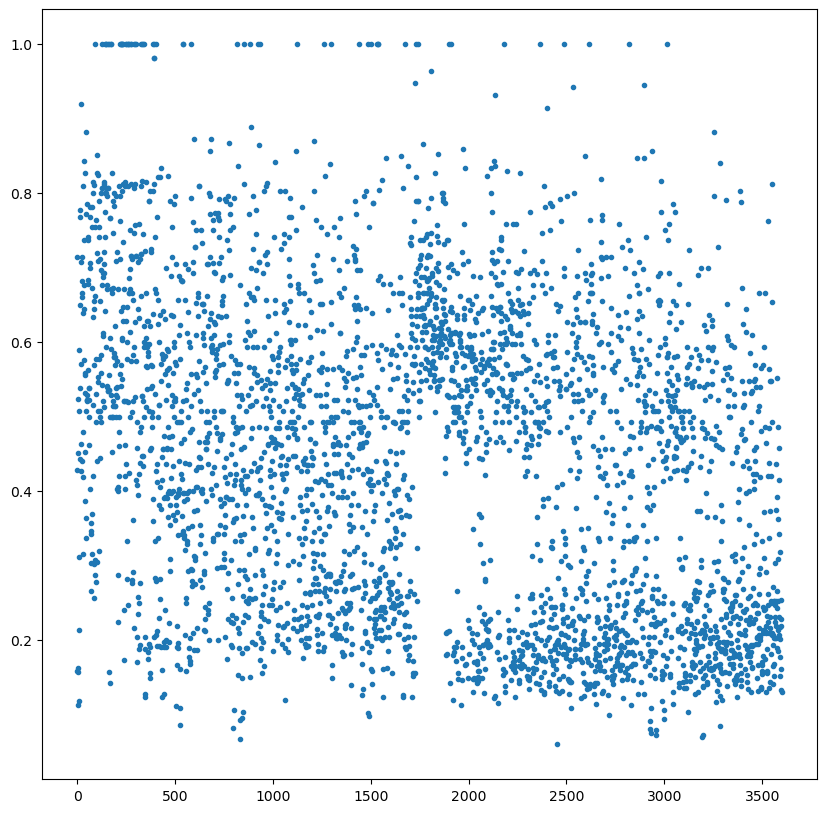

In [7]:
similarites = []
for last, current in zip(fps[:-1], fps[1:]):
    similarites.append(DataStructs.TanimotoSimilarity(last, current))

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(range(len(similarites)), similarites, marker=".")

In [8]:
npfps = np.zeros((len(fps), 2048))
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, npfps[i, :])

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings = pca.fit_transform(npfps)

<Axes: >

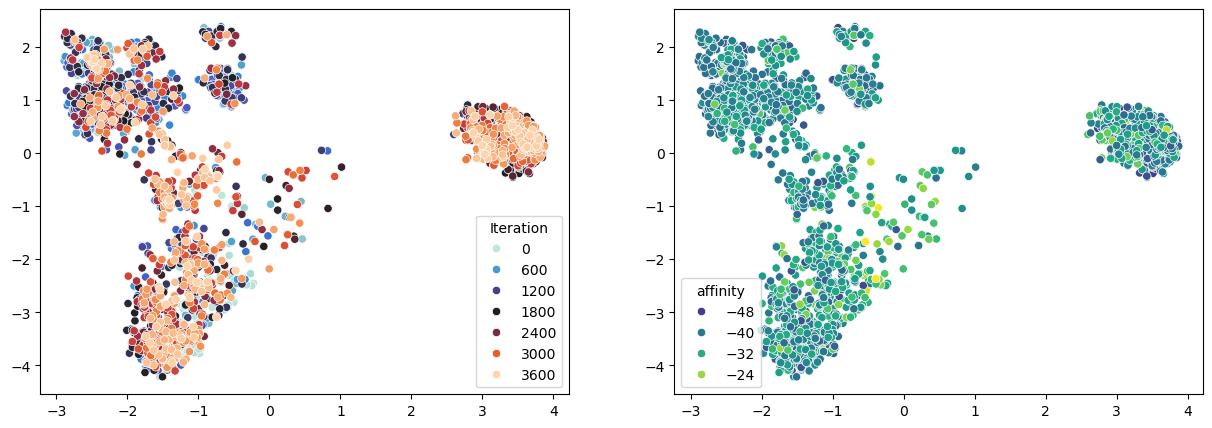

In [10]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], hue=df["Iteration"], palette="icefire", ax=ax1)
sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], hue=df["affinity"], palette="viridis", ax=ax2)

In [11]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from rdkit.Chem import Draw

fig, axes = plt.subplot_mosaic(
    [["scatter", "scatter"],
     ["progress", "mol"]],
    figsize=(8, 8),
    gridspec_kw={'height_ratios': [3, 1]}
)

ax1, ax2, ax3 = list(axes.values())
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)
ax1.set_title('Querying in chemical space')
ax1.set_xticks([])
ax1.set_yticks([])
ax3.axis("off")

# Initialize empty scatter plot
scatter = ax1.scatter([], [], c=[], cmap='viridis', s=100, alpha=0.7)
timestamp_text = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, fontsize=12)

progress_values = (df["is_top_k_cum"] / len(top_k)).values
progress = ax2.plot([], [], 'b-', linewidth=2)[0]
ax2.set_ylabel("% Retrieved")
ax2.set_xlabel("Iteration")
ax2.set_xlim(-0.5, 3601)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, alpha=0.3)

ax2.set_title("Retrieval progress")
ax3.set_title("Molecule queried in this iteration")
im = ax3.imshow(np.zeros((400, 400)))


# Add colorbar that will be updated
norm = Normalize(vmin=0, vmax=3601)  # Set max to your total frames
sm = ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax1, label='Iteration')

# Function to initialize the animation
def init():
    scatter.set_offsets(np.empty((0, 2)))
    scatter.set_array(np.array([]))
    timestamp_text.set_text('')
    
    im.set_data(np.zeros((400, 400)))
    progress.set_data([], [])
    return scatter, timestamp_text, progress, im

# Function to update for each frame
def update(frame):
    # Get data up to the current frame
    current_points = frame + 1
    current_x = embeddings[:current_points, 0]
    current_y = embeddings[:current_points, 1]
    
    # Update scatter plot with new data
    scatter.set_offsets(np.column_stack((current_x, current_y)))
    
    # Update color based on the index (to show progression)
    colors = np.arange(current_points)
    scatter.set_array(colors)
    
    # Update colorbar limits to match the current data range
    if len(colors) > 0:
        scatter.set_clim(0, 3601)  # This updates the color scale
    
    # Update timestamp text
    timestamp_text.set_text(f'Iteration: {frame}')
    
    # Update title with count of points shown
    ax1.set_title(f'Querying in chemical space ({current_points}/{len(df)} points)')

    # Update progress line
    iterations = df["Iteration"].iloc[:current_points].values
    progress.set_data(iterations, progress_values[:current_points])

    # Current molecule
    mol = Chem.MolFromSmiles(df.iloc[frame]["molecule"])
    molimg = Draw.MolToImage(mol,size=(400,400))
    molimg = np.asarray(molimg)
    im.set_data(molimg)
    
    return scatter, timestamp_text, progress

# Create the animation
animation = FuncAnimation(
    fig, 
    update, 
    frames=len(df),
    init_func=init,
    blit=True,
    interval=20,  # 10 ms between frames
    repeat_delay=1000  # 1 second delay before repeating
)

plt.tight_layout()
animation.save(f"{MODEL}.mp4")

<IPython.core.display.Javascript object>